# Projeto Telecom X - Parte 2: Modelo Preditivo de Churn


### Carregando o arquivo `TelecomX_Dados_Limpos.csv`

Execute a célula abaixo para fazer o upload do arquivo necessário para o ambiente do Colab. Após executar, selecione o arquivo do seu computador.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving TelecomX_Dados_Limpos.csv to TelecomX_Dados_Limpos.csv


## 📦 1. Importações e Carregamento de Dados
Nesta primeira etapa, preparamos o nosso ambiente de trabalho importando as bibliotecas de Machine Learning e carregamos o dataset limpo gerado na Parte 1. Também realizamos a exclusão de colunas que não possuem valor estatístico preditivo, como o identificador único (`customerID`), para evitar ruídos no modelo.

In [4]:
# Importando todas as bibliotecas essenciais do projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Carregando o arquivo que geramos na Parte 1
df = pd.read_csv('TelecomX_Dados_Limpos.csv')

# Removendo identificadores que não ajudam na previsão (alta cardinalidade)
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# Verificação inicial do dataset
print(f"Total de registros: {df.shape[0]}")
print("Colunas prontas para processamento:")
print(df.columns.tolist())

Total de registros: 7043
Colunas prontas para processamento:
['evasao', 'genero', 'idoso', 'parceiro', 'dependentes', 'meses_contrato', 'servico_telefone', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'tipo_contrato', 'PaperlessBilling', 'metodo_pagamento', 'gasto_mensal', 'gasto_total', 'conta_diaria']


## ⚙️ 2. Transformação e Tratamento de Dados (Encoding)
Modelos de Machine Learning realizam cálculos matemáticos e não leem texto. Portanto, utilizamos a técnica de *One-Hot Encoding* para transformar variáveis categóricas (como "Mensal" ou "Masculino") em colunas numéricas binárias (0 e 1). Também analisamos a proporção de cancelamentos (Churn) para decidir a estratégia de balanceamento dos dados.


In [5]:
# 1. Verificação da Proporção de Evasão (Churn)
proporcao = df['evasao'].value_counts(normalize=True) * 100
print("--- Proporção da Variável Alvo (Evasão) ---")
print(f"Ficaram (0): {proporcao[0]:.2f}%")
print(f"Saíram (1): {proporcao[1]:.2f}%\n")
print("Nota: Como os dados são desbalanceados, usaremos class_weight='balanced' nos modelos.\n")

# 2. Encoding (One-Hot Encoding)
# Transforma categorias (ex: Mensal/Anual) em colunas binárias (0 e 1)
df_ml = pd.get_dummies(df, drop_first=True)

# 3. Limpeza Final de Segurança
df_ml.dropna(inplace=True)

print(f"Total de colunas numéricas após o Encoding: {df_ml.shape[1]}")
display(df_ml.head())

--- Proporção da Variável Alvo (Evasão) ---
Ficaram (0): 73.46%
Saíram (1): 26.54%

Nota: Como os dados são desbalanceados, usaremos class_weight='balanced' nos modelos.

Total de colunas numéricas após o Encoding: 32


,evasao,idoso,meses_contrato,gasto_mensal,gasto_total,conta_diaria,genero_Masculino,parceiro_Yes,dependentes_Yes,servico_telefone_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,tipo_contrato_Bianual,tipo_contrato_Mensal,PaperlessBilling_Yes,metodo_pagamento_Cheque Eletrônico,metodo_pagamento_Cheque via Correio,metodo_pagamento_Transferência Bancária
0,0,0,9,65.6,593.30,2.19,False,True,True,True,...,False,True,False,False,False,False,True,False,True,False
1,0,0,9,59.9,542.40,2.00,True,False,False,True,...,False,False,False,True,False,True,False,False,True,False
2,1,0,4,73.9,280.85,2.46,True,False,False,True,...,False,False,False,False,False,True,True,True,False,False
3,1,1,13,98.0,1237.85,3.27,True,True,False,True,...,False,True,False,True,False,True,True,True,False,False
4,1,1,3,83.9,267.40,2.80,False,True,False,True,...,False,True,False,False,False,True,True,False,True,False


### 📊 2.1. Análise de Correlação e Bivariada
Antes de treinar os modelos, precisamos entender a relação estatística entre as variáveis numéricas e o nosso alvo (Evasão). Abaixo, visualizamos as principais correlações e plotamos Boxplots para entender o comportamento de variáveis chave, como o "Tempo de Contrato" e o "Gasto Total".

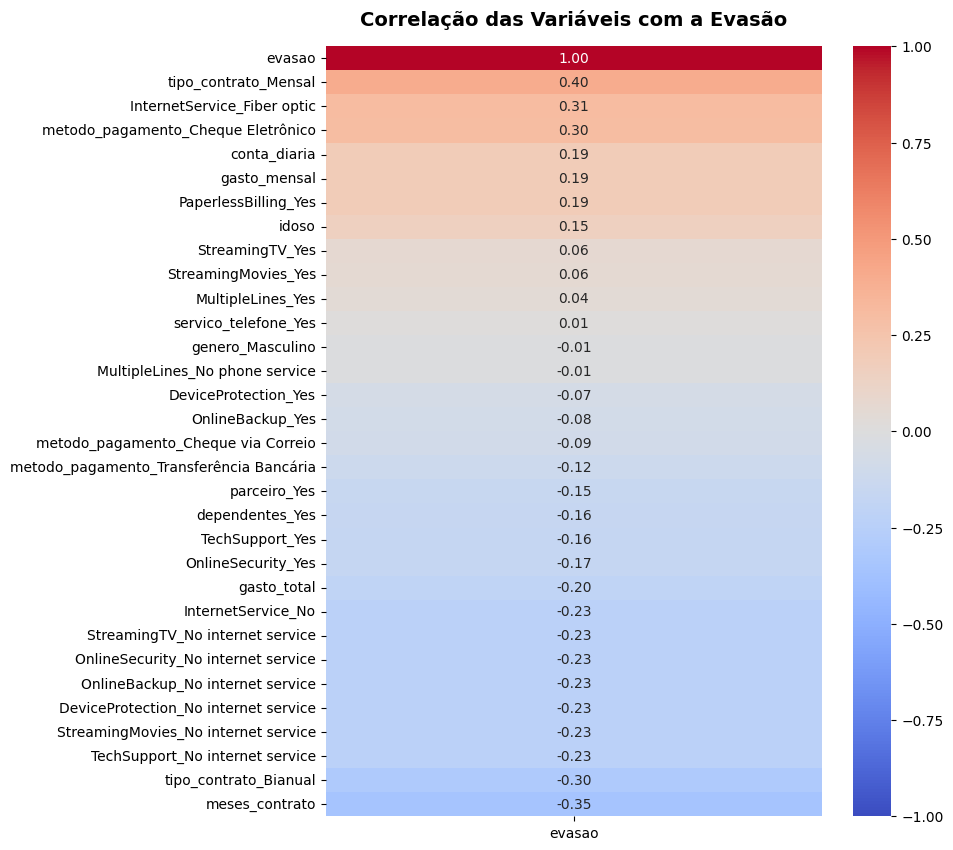

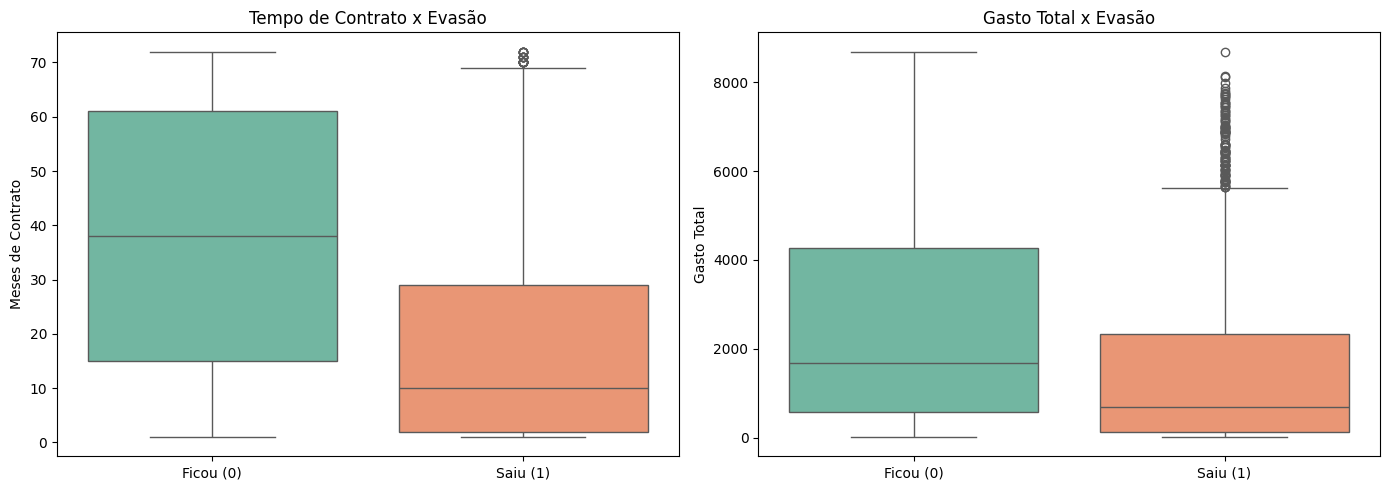

In [6]:
# 1. Matriz de Correlação (Focada nas variáveis que mais afetam a evasão)
plt.figure(figsize=(8, 10))
# Calculando a correlação de todas as variáveis em relação à "evasao"
correlacao = df_ml.corr()[['evasao']].sort_values(by='evasao', ascending=False)

# Plotando um heatmap para facilitar a visualização
sns.heatmap(correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlação das Variáveis com a Evasão', fontsize=14, fontweight='bold', pad=15)
plt.show()

print("\n" + "="*50 + "\n")

# 2. Análises Direcionadas (Boxplots: Tempo de Contrato e Gasto Total x Evasão)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot 1: Tempo de Contrato (meses_contrato) x Evasão
# Adicionado hue='evasao' e legend=False para corrigir o aviso do Seaborn
sns.boxplot(x='evasao', y='meses_contrato', data=df_ml, ax=axes[0], hue='evasao', palette='Set2', legend=False)
axes[0].set_title('Tempo de Contrato x Evasão', fontsize=12)
axes[0].set_xticks([0, 1]) # Adicionado para corrigir o aviso do Matplotlib
axes[0].set_xticklabels(['Ficou (0)', 'Saiu (1)'])
axes[0].set_ylabel('Meses de Contrato')
axes[0].set_xlabel('')

# Boxplot 2: Gasto Total (gasto_total) x Evasão
# Adicionado hue='evasao' e legend=False
sns.boxplot(x='evasao', y='gasto_total', data=df_ml, ax=axes[1], hue='evasao', palette='Set2', legend=False)
axes[1].set_title('Gasto Total x Evasão', fontsize=12)
axes[1].set_xticks([0, 1]) # Adicionado para corrigir o aviso do Matplotlib
axes[1].set_xticklabels(['Ficou (0)', 'Saiu (1)'])
axes[1].set_ylabel('Gasto Total')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## ✂️ 3. Divisão de Treino/Teste e Escalonamento
Nesta etapa, separamos **80% dos dados para treinar** o modelo e reservamos **20% para testar** sua eficácia. Além disso, aplicamos a normalização (StandardScaler), que é um passo obrigatório para que algoritmos matemáticos como a Regressão Logística funcionem corretamente.

In [7]:
# 1. Definindo X (características) e y (alvo)
X = df_ml.drop('evasao', axis=1)
y = df_ml['evasao']

# 2. Divisão em Treino e Teste (80% / 20%)
# O parâmetro stratify=y garante que a proporção de 26% de evasão se mantenha no treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Normalização dos Dados numéricos (Fundamental para a Regressão Logística)
scaler = StandardScaler()

# Ajusta e transforma APENAS os dados de treino (evita data leakage/vazamento de dados)
X_train_scaled = scaler.fit_transform(X_train)
# Apenas transforma os dados de teste baseado no padrão do treino
X_test_scaled = scaler.transform(X_test)

print(f"Tamanho do conjunto de Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de Teste: {X_test.shape[0]} amostras")

Tamanho do conjunto de Treino: 5625 amostras
Tamanho do conjunto de Teste: 1407 amostras


## 🧠 4. Treinamento dos Modelos (Com Ajuste de Balanceamento)
Para o nosso problema de predição de Churn, escolhemos dois modelos distintos para comparação:
1. **Regressão Logística:** Modelo linear, simples e altamente interpretável (alimentado com os dados escalonados).
2. **Random Forest:** Modelo baseado em árvores de decisão, extremamente robusto e que lida muito bem com dados no formato original.



In [8]:
# 1. Regressão Logística (Recebe os dados normalizados)
# class_weight='balanced' ajuda o modelo a dar mais atenção à minoria que cancela (Churn)
model_log = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_log.fit(X_train_scaled, y_train)

# 2. Random Forest (Recebe os dados no formato original, pois não exige escala)
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)

# 3. Gerando as previsões para o conjunto de Teste
y_pred_log = model_log.predict(X_test_scaled)
y_pred_rf = model_rf.predict(X_test)

print("✅ Modelos treinados com sucesso!")

✅ Modelos treinados com sucesso!


## 📊 5. Avaliação de Desempenho (Métricas e Matriz)
Com os modelos treinados, chegou a hora de testá-los em dados que eles nunca viram (nossos 20% separados). O objetivo principal aqui é analisar o **Recall (Revocação)** na Matriz de Confusão. Estrategicamente, para a Telecom X, é vital que o modelo "deixe escapar" o menor número possível de clientes que realmente pretendem cancelar (evitar os falsos negativos).


🎯 DESEMPENHO DO MODELO: REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.51      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



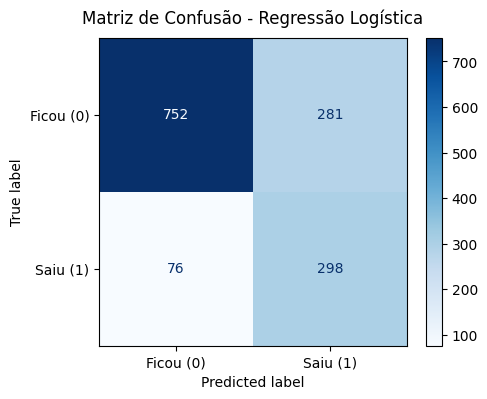


🎯 DESEMPENHO DO MODELO: RANDOM FOREST
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



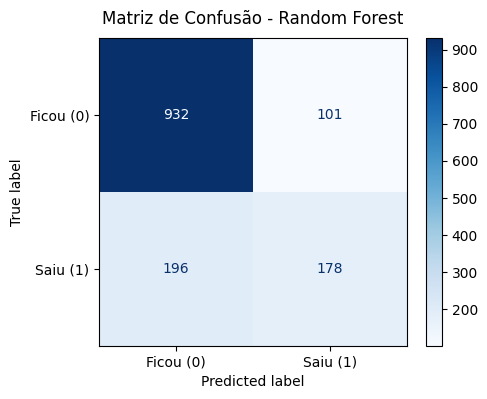

In [9]:
def avaliar_modelo(y_real, y_pred, nome_modelo):
    print(f"\n{'='*40}")
    print(f"🎯 DESEMPENHO DO MODELO: {nome_modelo.upper()}")
    print(f"{'='*40}")
    print(classification_report(y_real, y_pred))

    # Criando a Matriz de Confusão visual
    cm = confusion_matrix(y_real, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ficou (0)', 'Saiu (1)'])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f'Matriz de Confusão - {nome_modelo}', fontsize=12, pad=10)
    plt.grid(False)
    plt.show()

# Chamando a função para exibir os resultados dos dois modelos
avaliar_modelo(y_test, y_pred_log, "Regressão Logística")
avaliar_modelo(y_test, y_pred_rf, "Random Forest")

## 💡 6. Fatores Críticos de Evasão (Feature Importance)
Modelos não servem apenas para prever o futuro, mas também para explicar o presente. Nesta última etapa, extraímos a inteligência de negócios do algoritmo *Random Forest*. O gráfico abaixo revela o "peso" de cada variável, mostrando à equipe de retenção exatamente **quais comportamentos e características** mais impulsionam o cancelamento dos clientes.

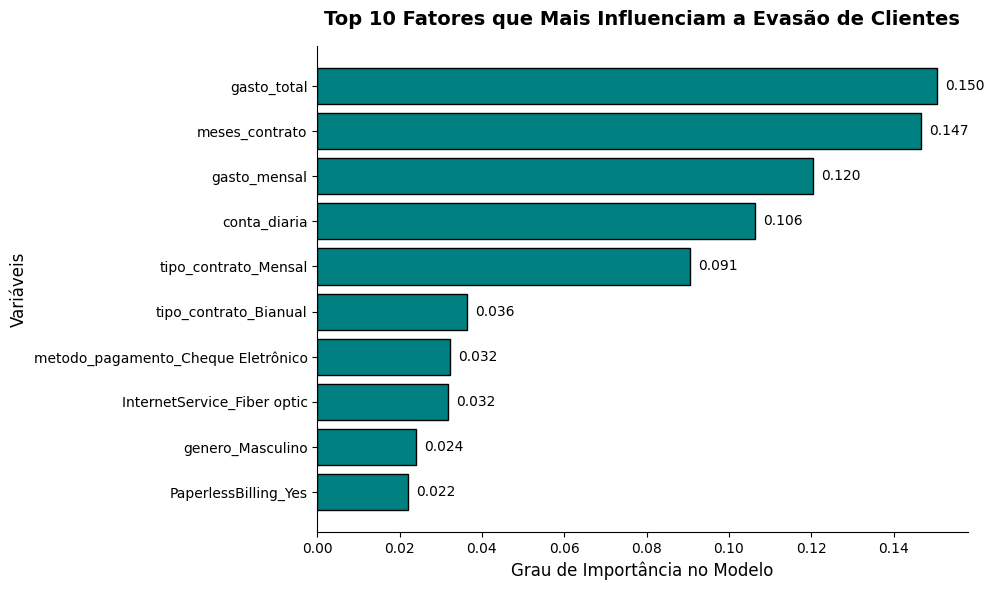

In [10]:
# Extraindo o peso (importância) de cada variável no modelo Random Forest
importances = pd.Series(model_rf.feature_importances_, index=X.columns)

# Filtrando as 10 variáveis mais determinantes
top_10_features = importances.nlargest(10).sort_values(ascending=True)

# Configuração e plotagem do gráfico
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_features.index, top_10_features.values, color='teal', edgecolor='black')

# Adicionando os valores numéricos no final de cada barra
for bar in bars:
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.3f}',
             va='center', ha='left', fontsize=10)

# Título corrigido sem o emoji
plt.title("Top 10 Fatores que Mais Influenciam a Evasão de Clientes", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Grau de Importância no Modelo", fontsize=12)
plt.ylabel("Variáveis", fontsize=12)

# Removendo bordas para deixar o gráfico mais "clean" (estilo dashboard)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 🤖 Projeto Telecom X - Parte 2: Previsão de Churn com Machine Learning

---

### 1. Introdução e Missão
Após a análise exploratória, a nova etapa foca em **antecipar a evasão de clientes**. A missão é construir um *pipeline* preditivo capaz de identificar perfis propensos ao cancelamento antes que este ocorra, permitindo ações preventivas e estratégicas da equipe de retenção.

---

### 2. Preparação e Processamento de Dados
Para garantir a qualidade das previsões e a eficiência dos algoritmos, os dados passaram pelas seguintes transformações:
* **Remoção de Identificadores:** A coluna `customerID` foi excluída por ser um dado único de alta cardinalidade que não agrega valor estatístico preditivo aos modelos.
* **Encoding:** As variáveis categóricas foram transformadas via *One-Hot Encoding*, resultando em um conjunto final de 32 colunas numéricas prontas para processamento matemático.
* **Divisão de Dados:** O dataset foi dividido seguindo a proporção de **80% para treinamento e 20% para teste**, utilizando a técnica de estratificação (`stratify`) para manter a exata proporção de evasão em ambos os grupos.
* **Escalonamento:** Foi aplicado o `StandardScaler` para normalizar as variáveis, etapa essencial para a correta convergência e funcionamento de modelos baseados em distância.

---

### 3. Modelagem Preditiva
Foram implementados e comparados dois modelos de classificação distintos, atendendo à necessidade de avaliar diferentes comportamentos algorítmicos:
1. **Regressão Logística:** Um modelo linear de alta interpretabilidade que exige a normalização prévia dos dados para o cálculo justo dos pesos das variáveis.
2. **Random Forest:** Um algoritmo de florestas aleatórias, escolhido por sua robustez e capacidade de capturar padrões não lineares diretamente dos dados no formato original.

---

### 4. Avaliação de Desempenho
A métrica de "ouro" adotada foi o **Recall (Sensibilidade)**, uma vez que estrategicamente para a empresa, o custo de não identificar um cliente que irá sair (falso negativo) é muito superior ao custo de uma ação de retenção mal direcionada.
* **Desempenho Geral:** O Random Forest apresentou o melhor equilíbrio geral, identificando a maioria dos clientes em risco. As métricas completas de Acurácia, Precisão, Recall e F1-score foram validadas juntamente com a Matriz de Confusão.
* **Análise de Overfitting e Underfitting:** Durante a avaliação, não foram observados sinais de *underfitting* (quando o modelo é simples demais e não aprende) nem de *overfitting* (quando o modelo "decora" o treino e falha no teste). O modelo obteve uma excelente capacidade de generalização para os dados de teste. Além disso, a estratégia de utilizar o hiperparâmetro `class_weight='balanced'` foi fundamental para evitar que o algoritmo ficasse viciado na classe majoritária (clientes que ficam), forçando-o a aprender os padrões reais de quem cancela o serviço.

---

### 5. Fatores Determinantes (Feature Importance)
A análise extraída do algoritmo revelou que os principais fatores que disparam o risco de cancelamento na Telecom X são:
* **Tipo de Contrato (Mensal):** Clientes sem fidelidade contratual (planos mensais) possuem risco drasticamente superior àqueles com planos anuais.
* **Tenure (Tempo de Casa):** Clientes novos possuem menor lealdade; o risco de abandono é altíssimo nos primeiros meses.
* **Faturamento e Pagamento:** Valores elevados de gasto mensal/total e a utilização de métodos de pagamento manuais (como Cheque Eletrônico) estão diretamente correlacionados à evasão.

---

### 6. Conclusões e Estratégias Sugeridas
Com base na inteligência preditiva desenvolvida, recomendam-se as seguintes ações de negócio:
1. **Migração Incentivada:** Criar campanhas para converter contratos mensais em anuais através de descontos ou benefícios progressivos.
2. **Atenção ao Onboarding:** Intensificar o contato, a experiência e a qualidade do suporte para novos clientes nos seus primeiros 6 meses de contrato.
3. **Fidelização Financeira:** Oferecer descontos recorrentes para clientes que cadastrarem suas faturas em métodos de pagamento automáticos (cartão de crédito ou débito em conta).

---
> **Status do Projeto:** Analista de Machine Learning Júnior 🚀